I am working on this source: https://archive.ics.uci.edu/dataset/360/air+quality

The goal is to predict air quality from environmental sensors

In [2]:
from pathlib import Path
import pandas as pd

# Path to the CSV file in the current working directory
csv_path = Path.cwd() / "AirQualityUCI.csv"

# If the file uses semicolons or comma decimals (common for some UCI datasets):
df = pd.read_csv(csv_path, sep=';', decimal=',')

# Quick checks
print(df.shape)
df.head()

(9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


# Define Regression problem
The goal is to predict air quality from environmental sensors

The targets are:
1. CO(GT)
2. NMHC(GT)
3. C6H6(GT)
4. NOx(GT)
5. NO2(GT)

The features are:
1. PT08.S1(CO)
2. PT08.S2(NMHC)
3. PT08.S3(NOx)
4. PT08.S4(NO2)
5. PT08.S5(O3)
6. T
7. RH
8. AH


## Exploratory Data Analysis

**Exploratory Data Analysis (EDA)** is the process of investigating and visualizing raw datasets to uncover their main characteristics, patterns, anomalies, and relationships. It's a crucial first step in any data science project before modeling.

### Key Goals of EDA:
- **Understand the data structure**: Shape, data types, missing values
- **Identify patterns & trends**: Distributions, correlations, outliers
- **Generate insights**: Find relationships between variables
- **Detect data quality issues**: Missing values, duplicates, inconsistencies
- **Inform modeling**: Choose appropriate algorithms based on data characteristics

### Common EDA Techniques:
- **Descriptive statistics**: Mean, median, std, min, max
- **Data visualization**: Histograms, boxplots, scatter plots, heatmaps
- **Correlation analysis**: Identify relationships between features
- **Outlier detection**: Identify and understand anomalies
- **Missing data assessment**: Evaluate gaps and imputation needs

In [3]:
# Data shape
print("Dataset Shape:", df.shape)
print("\n" + "="*50)

# Data types
print("\nData Types:")
print(df.dtypes)
print("\n" + "="*50)

# Missing values
print("\nMissing Values:")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing.values,
    'Missing_Percent': missing_percent.values
})
print(missing_df)
print("\nTotal missing values:", df.isnull().sum().sum())

Dataset Shape: (9471, 17)


Data Types:
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object


Missing Values:
           Column  Missing_Count  Missing_Percent
0            Date            114         1.203674
1            Time            114         1.203674
2          CO(GT)            114         1.203674
3     PT08.S1(CO)            114         1.203674
4        NMHC(GT)            114         1.203674
5        C6H6(GT)            114         1.203674
6   PT08.S2(NMHC)            114         1.203674
7         NOx(GT)            114         1.203674
8    PT08.S3(NOx)            114         1.203674
9  

It seems that 15 and 16 can maybe be dropped

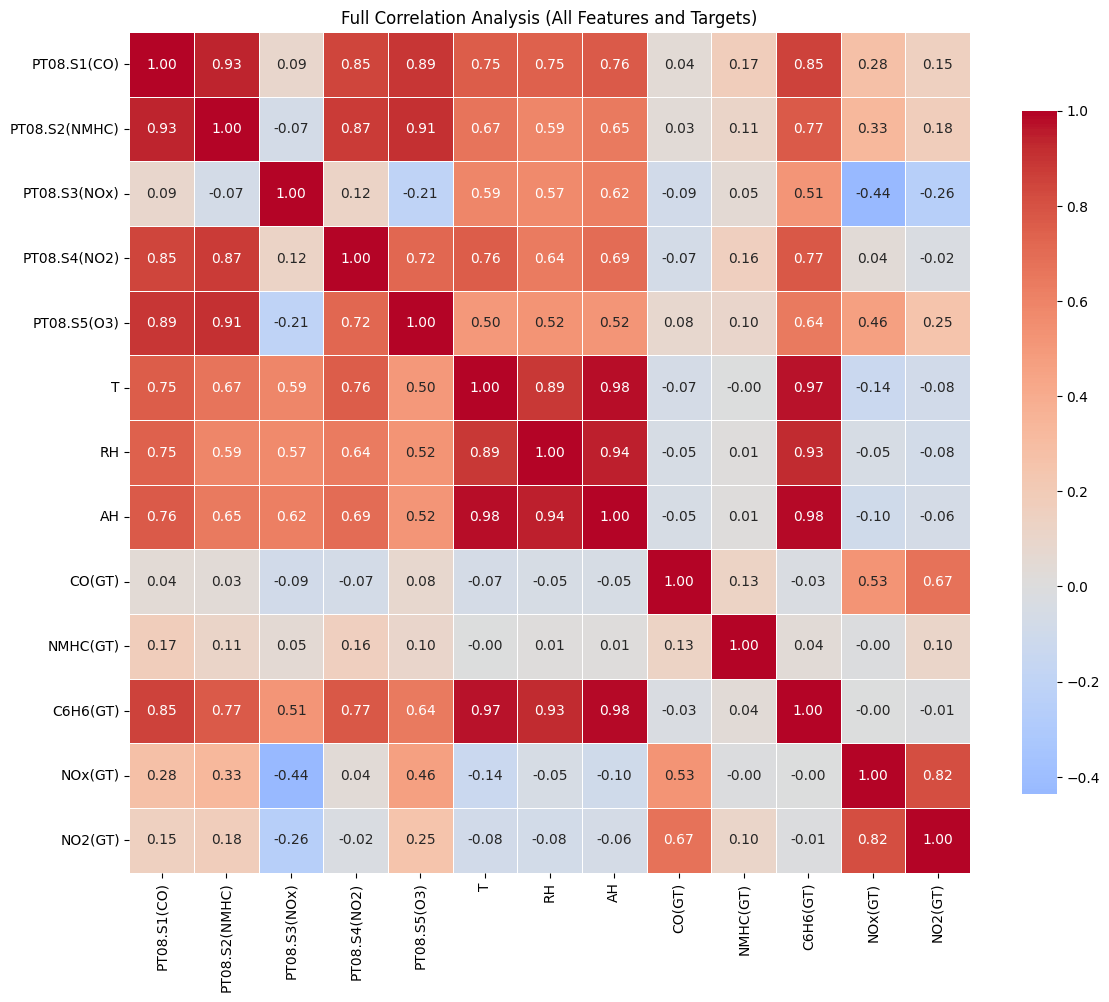

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define features and targets from the regression problem
features = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 
            'PT08.S5(O3)', 'T', 'RH', 'AH']
targets = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

# Combine features and targets
all_columns = features + targets

# Select only these columns that exist in the dataframe
selected_columns = [col for col in all_columns if col in df.columns]

# Calculate correlation matrix
correlation_matrix = df[selected_columns].corr()

# Create visualization 1: Full correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Full Correlation Analysis (All Features and Targets)')
plt.tight_layout()
plt.show()


This was overwhelming! Lets simplify!

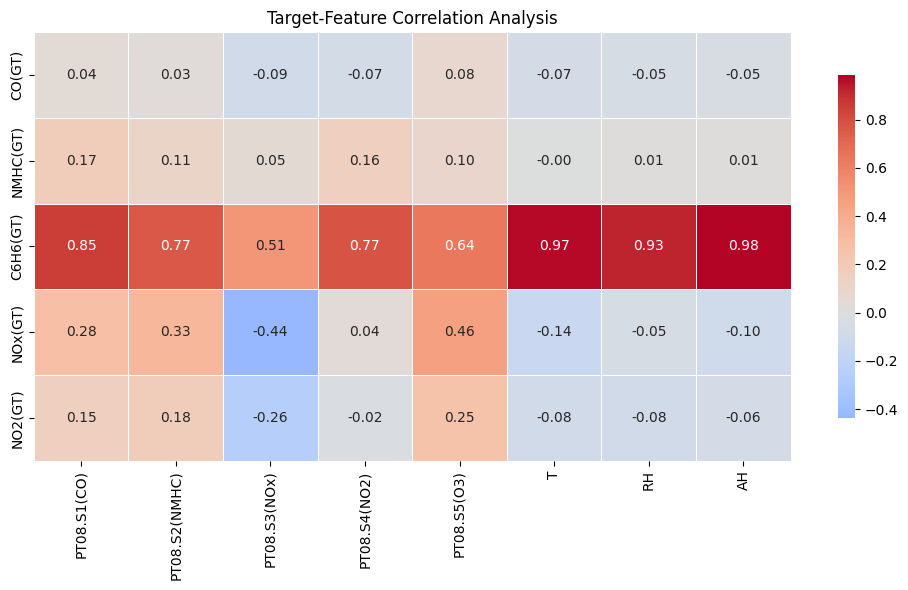

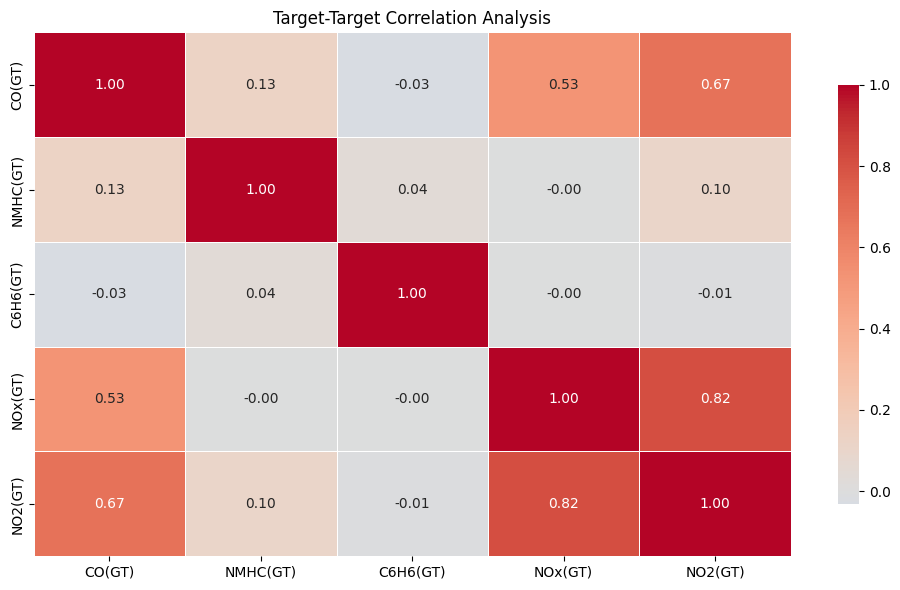

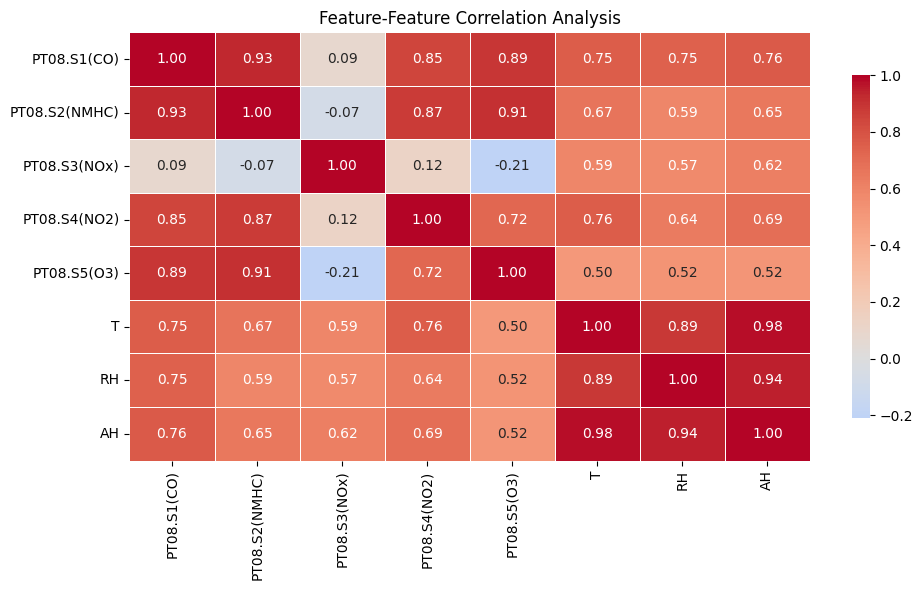

Correlation between each target and the features:

CO(GT):
PT08.S5(O3)      0.080310
PT08.S1(CO)      0.041411
PT08.S2(NMHC)    0.029926
AH              -0.045892
RH              -0.048227
T               -0.068939
PT08.S4(NO2)    -0.073724
PT08.S3(NOx)    -0.089981
Name: CO(GT), dtype: float64

NMHC(GT):
PT08.S1(CO)      0.170007
PT08.S4(NO2)     0.162680
PT08.S2(NMHC)    0.110104
PT08.S5(O3)      0.101185
PT08.S3(NOx)     0.048821
AH               0.012500
RH               0.008284
T               -0.000009
Name: NMHC(GT), dtype: float64

C6H6(GT):
AH               0.984555
T                0.971375
RH               0.925062
PT08.S1(CO)      0.852687
PT08.S4(NO2)     0.774673
PT08.S2(NMHC)    0.767433
PT08.S5(O3)      0.641334
PT08.S3(NOx)     0.512193
Name: C6H6(GT), dtype: float64

NOx(GT):
PT08.S5(O3)      0.461889
PT08.S2(NMHC)    0.331272
PT08.S1(CO)      0.277993
PT08.S4(NO2)     0.035546
RH              -0.053009
AH              -0.095847
T               -0.138452
PT08.S3(NOx)

In [11]:

# Create visualization 2: Target-Feature correlation matrix only
# Extract correlations between targets and features
target_feature_corr = correlation_matrix.loc[targets, features]

plt.figure(figsize=(10, 6))
sns.heatmap(target_feature_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Target-Feature Correlation Analysis')
plt.tight_layout()
plt.show()

# Create visualization 3: Target-Target correlation matrix only
# Extract correlations between targets and targets
target_target_corr = correlation_matrix.loc[targets, targets]

plt.figure(figsize=(10, 6))
sns.heatmap(target_target_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Target-Target Correlation Analysis')
plt.tight_layout()
plt.show()

# Create visualization 4: Feature-Feature correlation matrix only
# Extract correlations between feature and features
feature_feature_corr = correlation_matrix.loc[features, features]

plt.figure(figsize=(10, 6))
sns.heatmap(feature_feature_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature-Feature Correlation Analysis')
plt.tight_layout()
plt.show()

# Display correlation between each target and all features
print("Correlation between each target and the features:")
print("="*50)
for target in targets:
    if target in df.columns:
        print(f"\n{target}:")
        # Only show correlations with features
        corr_with_target = correlation_matrix.loc[features, target].sort_values(ascending=False)
        print(corr_with_target)

An issue is that most features correlate strongly, which means that each of them dont bring too much additional information

There is not too much correlation between targets and features, so whatever sensors were used were not too great... Lets see if we can still use it to get good predictions!